# Lesson 2: Tabular Data with Pandas

In this lesson, we will explore how to work with tabular data using the `pandas` Python libraray.

When it comes to tabular data (i.e., data with labelled rows and columns), `pandas` is your best friend. It lets you take all types of tabulated data (including large datasets with millions or rows) and inspect and modify them. Since it makes data look somewhat like a spreadsheet, it should be somewhat intuitive for those familiar working with e.g., Excel, or Google Sheets. If you've ever used a Pivot Table in Excel, then... yup, `pandas` can do those too.

While we will only have time to cover some of the basics of pandas, you will hopefully leave with an appreciation that tabular data is a common data format in science and that pandas is an extremely powerful tool for working with this data.

### Learning outcomes

After this lesson, you should be able to:

1) Understand what a library is in Python.
2) Identify the appropriate indexing commands to access values in a pandas DataFrame.
3) Apply pandas dataframe functions to extract aggregate statistics of data.
4) Create datetime objects from date strings.
5) Recall the most common tabular data file formats and the corresponding pandas read commands.
6) Appreciate the importance of following a data opening checklist each time we open a data file.  

:::{danger}
## Entry ticket!

This is your ticket into the lesson. Before we start, discuss with your neighbor for 60 seconds the concept you found the most challenging from the last lesson.
:::

# Introduction to tabular data and pandas

We can think of tabular data as data that would fit in an Excel spreadsheet, with organized rows and columns. In `pandas` this is called a `DataFrame`. As well as column names, a `DataFrame` has an index which is the number that represents the row position.

The other type of data structure in `pandas` is a `Series`, essentially a simpler version of a `DataFrame` that represents a single column only.

We can create a `pd.DataFrame` from scratch (for example using a dictionary) or we can read in data from a file, often in csv format.

![summary_pandas](images/summary_pandas.jpg)

:::{admonition}
### Exercise 1: Real-world tabular data

Before we dive into working with tabular data, think of three different types of tabular data. In each case, what do the column (or columns) and rows represent? Spend 60 seconds, then discuss with your neighbor for another 30 seconds.

:::

## Importing libraries

`Pandas` is like any other Python library in that we need to import it to be able to use it.

Taking a step back, a **library** is a like an "extras" package for a programming language.  It is a set of commands that doesn't automatically come activated when you use Python, but that you can still use if you just tell Python that you plan to do so.  You let python know you are going to use a library with an `import` statment. After that, additional commands become available for us to use.

In [62]:
# Let's define some fake data with a dictionary
forecast_dict = {
    'temperature': [25, 20, 27, 31], 
    'humidity': [60, 65, 62, 80],
    'wind_speed': [10, 9, 10, 6]
}

# Now let's use it to create a pandas dataframe
forecast = pd.DataFrame(forecast_dict)

:::{warning}
## Bug alert!

`NameError: name 'pd' is not defined`

Another `NameError`! We attempted to use a pandas function but we failed to import the pandas library first. The computer doesn't know what `pd` is because we have not imported the pandas library and assigned to the name `pd` yet.

In [5]:
# Import the libary - you only have to do this once per file.
import pandas as pd

In [64]:
# These settings optional change the way in which pandas data is displayed in the notebook
pd.set_option('display.max_rows', 10)
pd.set_option('display.max_columns', 15)

## Anatomy of a DataFrame

In [13]:
# Let's create our first data frame using some fake data in a dictionary
forecast_dict = {
    'temperature': [25, 20, 27, 31], 
    'humidity': [60, 65, 62, 80],
    'wind_speed': [10, 9, 10, 6]
}
forecast = pd.DataFrame(forecast_dict)
forecast

,temperature,humidity,wind_speed
0,25,60,10
1,20,65,9
2,27,62,10
3,31,80,6


:::{admonition}
### Exercise 2: Components of a DataFrame

Label the boxed components of the dataframe.

![examples_dataframe](images/pandas_checkin.png)

Answers reference the figure in the order: green, purple, red, orange. Pick one answer from options a-e.

a) (1) 1 row of data, (2) data series, (3) column names, (4) indexes

b) (1) indexes, (2) data series, (3) 1 row of data, (4) column names

c) (1) indexes, (2) 1 row of data, (3) data series, (4) column names

d) (1) column names, (2) data series, (3) 1 row of data, (4) indexes

e) (1) column names, (2) 1 row of data, (3) data series, (4) indexes

:::

## Accessing values in a DataFrame

Even though pandas dataframes are new data structures, some of the patterns for accessing data are very similar to what we saw in the list and dictionary data structures.  What's exciting is that the concept of indexing is conceptually similar and so in response the syntax is also similar.

Some of the main ways you may want to access data in a dataframe might be:
1. Look at __all the data in a single column__
2. Look at __all the data in a single row__
3. Look at __a specific cell (single column and row location)__

When looking up data for a row we use the indexes, and the same `[]` syntax that we have seen in lists.  `pandas` uses the `[]` and `:` notation in the exact same way. 

Remember, the index is an important part of your organization of your data.  
> The most important part of in index is that it is **unique**, meaning no two rows of data is allowed to have the same index.

### `loc` and `iloc`

The new syntax we need to learn for working with `pandas` is `iloc` and `loc`. This is the syntax that goes before the square brackets `[]` when we access values in a dataframe.

* `.loc` stands for location-based indexing, and allows us to select rows and/or columns using their __labels (names)__.
* `.iloc` stands for integer-location-based indexing, and allows us to select rows and/or columns using their __integer positions.__
  
We can apply both `.loc` and `.iloc` to rows, columns, or both.

![loc_v_iloc](images/loc_v_iloc.png)

_Image from [The PyCoach on Medium](https://medium.com/data-science/loc-vs-iloc-in-pandas-heres-the-difference-16cd4bcbecab)_

:::{admonition} Vocabulary
When we take one or multiple rows or columns from a dataframe using `:`, this is commonly known as **slicing**. Imagine taking a slice out of your dataframe like you slice a cake!

In [14]:
# Viewing a series (column) of data from a dataframe.
forecast['humidity']

0    60
1    65
2    62
3    80
Name: humidity, dtype: int64

In [15]:
# Display just the row of index 2
forecast.iloc[2]

temperature    27
humidity       62
wind_speed     10
Name: 2, dtype: int64

In [17]:
# Display just the single value in row of index 2, column of index 1
forecast.iloc[2, 1]

62

In [18]:
# Display rows index 2-3, slicing
forecast.iloc[2:4]

,temperature,humidity,wind_speed
2,27,62,10
3,31,80,6


In [19]:
# Display first row and columns index 1-2 and 
forecast.iloc[0, 1:3]

humidity      60
wind_speed    10
Name: 0, dtype: int64

In [70]:
# Column names
forecast.columns

Index(['temperature', 'humidity', 'wind_speed'], dtype='object')

In [71]:
# Index values
forecast.index

RangeIndex(start=0, stop=4, step=1)

:::{admonition} Vocabulary
Accessing information about an object using a `.` (like `.columns`) is called accessing an __attribute__ or a __property__ of an object. Revisiting our language analogy where objects are nouns and functions are verbs, __we can think of attributes as adjectives.__
:::

:::{admonition}
### Exercise 3: Accessing values in a DataFrame

1. Write a line of code to get just the `wind_speed` column.
  
2. Write a new line of code to get just the row of index 3.

3. What is the value of `forecast['humidity'].iloc[2]`?

a) the row: 27 62 10

b) the column: 60 65 62 80

c) the row: 20 65 9

d) 65

e) 62

Spend 3 minutes then discuss with your neighbor for another minute.

:::

### What if our index was made up of text information rather than integers?

This is where we need to switch to using `loc` instead of `iloc`.

In [9]:
# Let's create our first data frame using some fake data in a dictionary
forecast_dict = {
    'temperature': [25, 20, 27, 31], 
    'humidity': [60, 65, 62, 80],
    'wind_speed': [10, 9, 10, 6],
    'analyst_on_duty': ['Johan', 'Priya', 'Ángel', 'Martha']
}
forecast = pd.DataFrame(forecast_dict)
forecast = forecast.set_index('analyst_on_duty')
forecast

,temperature,humidity,wind_speed
analyst_on_duty,,,
Johan,25,60,10
Priya,20,65,9
Ángel,27,62,10
Martha,31,80,6


In [10]:
# Now we use the analyst names (labels) to index the rows
forecast.loc['Johan']

temperature    25
humidity       60
wind_speed     10
Name: Johan, dtype: int64

In [12]:
# Accessing single value using both row and column names and loc
forecast.loc['Priya', 'temperature']

20

Note that using these methods to access values in a `DataFrame` does not change the original `DataFrame`. For that we'll need to assign our selection to a new (or the same) variable. More on changing values in a `DataFrame` later!

In [72]:
# Updating the forecast variable with just the two rows
forecast = forecast.iloc[2:4]

# `forecast was updated`
forecast

,temperature,humidity,wind_speed
2,27,62,10
3,31,80,6


## DataFrame functions/methods

There are many functions/methods for working with `pd.DataFrames` and `pd.Series`. Here is a summary of just some the most common:

| Function / Method   | Description | Note about arguments |
|:---|:---|:---|
| `info()` |  provides information about the dataframe| `verbose=True` to also show name and data type of columns|
| `describe()` |  provides descriptive statistics of the data| |
| `dropna()` |  drops missing values| `axis=0` to perform by row or `axis=1` to perform by column|
| `fillna()` |  fills missing values with another value| argument is value we want to fill with|
| `head(n)` |  displays the first n ows| argument is the number of rows we want to display from the first row|
| `tail(n)` |  displays the last n rows| argument is the number of rows we want to display from the last row|
| `astype()` |  change the data type| argument is the desired data type e.g. `int`, can be applied to a column, row, or entire dataframe|
| `count()` |  count the number of non-missing cells for each column or row| `axis=0` or `1`, `numeric_only=True` to count only numeric data (ignore strings)|
| `unique()` |  return unique values| |
| `value_counts()` |  returns unique values and the number of times they occurred| |
| `T` |  tranpose the dataframe| |


This is just a flavor of the available funtions. Read the documentation for more: https://pandas.pydata.org/docs/reference/frame.html 

## Working with real-life tabular data

To work with the `pandas` library we'll use as an example some streamgauge data from the US Geogological Survey. You can view the original data at: https://waterdata.usgs.gov/monitoring-location/USGS-06711565/. Note that the Excel data we will be working with was modified slighlty from the original website output.

:::{hint}
# File formats: xlsx, CSV, txt 
In our streamgauge example, the data is in an Excel (`.xlsx`) file format. Other typical file formats for tabular data include `CSV` and `txt`. The key idea when opening the data with pandas is providing the correct **separator** (`sep`), the symbol (`,`,`|`,`\t`, etc.) that separates the data in each of the columns. Luckily for us, providing the data is in a standard format, `pandas` should be able to figure this out automatically.

| File format | Description | Reading with pandas |
|:---|:---|:---|
| `xlsx` | MS Excel spreadsheet| `pd.read_excel()`, can optionally specify which tab to open with `sheet_name='tabname'`|
| `csv` | Comma-Separated Values, as per the name values are separated by comma delimeter, looks just like a Excel spreadsheet but without the fancy formatting|  `pd.read_csv()`|
| `txt` | simple text file, the delimeter could be anything so worth opening the file in a text editor to check|  `pd.read_csv(sep="\t")` or whatever delimeter is used, `pd.read_table()` uses tab `\t` as default|


There are a few arguments you may need depending on the contents of the tabular data file you are trying to open. These all work inside of the `pd.read_xxx()` family of commands:

| Argument | Description |
|:---|:---|
| `header`| can specify index position of the header row (if different from the first row)|
| `names`| can manually provide columns names upon reading the data|
| `index_col`| can specify index position of the column to use as the dataframe index|
| `dtype`| can manually specify the desired data type for entire data or each column upon reading the data|
| `skiprows`| number of rows at start to skip when reading|

:::

In [73]:
# To open excel data, we'll first need to install an extra package dependency
!pip install openpyxl -qq

In [74]:
# Read in the data
filepath = 'data/usgs_streamgauge_06711565.xlsx'
gauge = pd.read_excel(filepath)

FileNotFoundError: [Errno 2] No such file or directory: 'data/usgs_streamgauge_06711565.xlsx'

:::{warning}
## Bug alert!

`FileNotFoundError: [Errno 2] No such file or directory: 'data/usgs_streamgauge_06711565.xlsx'`

We mistakenly gave the wrong file path. The computer tries to load this filepath but finds no file at this location.

### A brief note on file paths and folder organization

![File Structure](images/computer_structure.png)

Figure from [ResearchGate](https://www.researchgate.net/figure/Overview-of-structure-of-folders-for-tool_fig1_332775326)

Your computer is organized **hierarchically**. When loading data, we have to tell the computer where to look for the data file. This is called the **filepath** and it is a string that describes the location of the data that you want to open. A few pieces of the anatomy of a filepath to take note of:
* `/`: forward slashes signal that you have entered a new folder. (Windows machines natively use a back slash `\`, but the Anaconda powershell can handle either.)
* `.xlsx`: this is the file extension, which tells us what type of file format the data is stored in an informs us how we open it.
* `.`: a period at the beginning tells the computer to start looking for data in the same place that the code is being run in.
* `../`: this double period followed by a slash tells the computer to start looking for data in one directory up from where we are running the code.  

Choosing to start your filepath with a `.` is called specificying a **relative filepath**, because you are telling the computer to start looking for the file relative to where the file is being run. If you move this file to another place on your computer and don't move the data with it the import statment won't work anymore. 

The alternative to a relative filepath is an **aboslute filepath**, in which case you start your file path at the very tippy top of your computer's organizational structure (the root directory).

Other vocab notes: **directory** means the same as a folder.

In [75]:
# Read in the data - this time specify correct filepath
filepath = '../data/usgs_streamgauge_06711565.xlsx' # this time we fixed the relative path
gauge = pd.read_excel(filepath)
gauge.head(8) # show the first eight rows

,x,y,id,agency_code,agency_name,monitoring_location_number,monitoring_location_id,monitoring_location_name,parameter_code,statistic_id,time,T_degC,Q_ft3s-1,approval_status
0,-105.004181,39.66498,USGS-06711565,USGS,U.S. Geological Survey,6711565,USGS-06711565,"SOUTH PLATTE RIVER AT ENGLEWOOD, CO.",10,11,2026-05-27 21:15:00+00:00,18.8,46.6,Provisional
1,-105.004181,39.66498,USGS-06711565,USGS,U.S. Geological Survey,6711565,USGS-06711565,"SOUTH PLATTE RIVER AT ENGLEWOOD, CO.",10,11,2026-05-27 21:00:00+00:00,18.8,48.7,Provisional
2,-105.004181,39.66498,USGS-06711565,USGS,U.S. Geological Survey,6711565,USGS-06711565,"SOUTH PLATTE RIVER AT ENGLEWOOD, CO.",10,11,2026-05-27 20:45:00+00:00,18.7,48.7,Provisional
3,-105.004181,39.66498,USGS-06711565,USGS,U.S. Geological Survey,6711565,USGS-06711565,"SOUTH PLATTE RIVER AT ENGLEWOOD, CO.",10,11,2026-05-27 20:30:00+00:00,18.7,48.7,Provisional
4,-105.004181,39.66498,USGS-06711565,USGS,U.S. Geological Survey,6711565,USGS-06711565,"SOUTH PLATTE RIVER AT ENGLEWOOD, CO.",10,11,2026-05-27 20:15:00+00:00,18.6,48.7,Provisional
5,-105.004181,39.66498,USGS-06711565,USGS,U.S. Geological Survey,6711565,USGS-06711565,"SOUTH PLATTE RIVER AT ENGLEWOOD, CO.",10,11,2026-05-27 20:00:00+00:00,18.6,48.7,Provisional
6,-105.004181,39.66498,USGS-06711565,USGS,U.S. Geological Survey,6711565,USGS-06711565,"SOUTH PLATTE RIVER AT ENGLEWOOD, CO.",10,11,2026-05-27 19:45:00+00:00,18.5,48.7,Provisional
7,-105.004181,39.66498,USGS-06711565,USGS,U.S. Geological Survey,6711565,USGS-06711565,"SOUTH PLATTE RIVER AT ENGLEWOOD, CO.",10,11,2026-05-27 19:30:00+00:00,18.5,50.8,Provisional


In [76]:
gauge.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35024 entries, 0 to 35023
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   x                           35024 non-null  float64
 1   y                           35024 non-null  float64
 2   id                          35024 non-null  object 
 3   agency_code                 35024 non-null  object 
 4   agency_name                 35024 non-null  object 
 5   monitoring_location_number  35024 non-null  int64  
 6   monitoring_location_id      35024 non-null  object 
 7   monitoring_location_name    35024 non-null  object 
 8   parameter_code              35024 non-null  int64  
 9   statistic_id                35024 non-null  int64  
 10  time                        35024 non-null  object 
 11  T_degC                      35024 non-null  float64
 12  Q_ft3s-1                    34834 non-null  float64
 13  approval_status             350

:::{admonition}
### Exercise 4: Inspecting summary info about a DataFrame

Using the output from `.info()`, can you answer:

1. How many unique data types are present in our data we just read with `pandas`?
  
2. How many columns of data do we have? How many total rows of data do we have?

3. How many valid rows (i.e., without missing values) of discharge data do we have? How many missing values are there in our discharge data? (The symbol for discharge is Q.) 

Spend 120 seconds then discuss with your neighbor for 60 seconds.

:::

`````{tip} 
## Data Opening Checklist

So this exercise of inspecting summary information demonstrates part of what we should do more generally every time we open a dataset. The first thing we should do when we open a data file is to check the contents and compare that to our expectation. Think of it like opening an unexpected package in the mail -- you might have a guess what's inside, but you need to get into it to look around and perhaps checke the receipt to be sure of what it is and where it came from.

In general, when opening a dataset you'll always want to go through the same couple checks:


1. What variables or measurements are available in this dataset?
2. How is the dataset organized? What is the shape or size?
3. What spatial and/or temporal range does this dataset cover?
4. Do there appear to be any nodata values in this dataset?
5. Do the variables appear to have reasonable values?
6. Make the simplest plot possible of 1-2 variables. Does it match your expectations?
`````

## Data cleaning / preparation

This isn't something you need to learn how to do right now, but you will be exposed to it the more you start working with real-world data. And it can be a time-consuming component of scientific research. 

There are lots of ways we can clean up and prepare tabular data to make it more manageable before we start to properly inspect and analyze it. Each dataset often requires its own data cleaning appraoch. Here, we demonstrate just a few common techniques to give you a sense (don't worry about remembering all of these!)

In [77]:
# Show the shape of our dataframe we start with
print(gauge.shape) # (rows, columns)

# Remove any columns that only contain "NaN" (missing values)
gauge = gauge.dropna(axis=1, how='all')

# Keep only columns we are interested in - see how we provide a list of the column names we want to keep, inside of the [] brackets
gauge = gauge[['time', 'T_degC', 'Q_ft3s-1', 'approval_status']]

# Ensure temp and discharge columns are float values
gauge[['T_degC', 'Q_ft3s-1']] = gauge[['T_degC', 'Q_ft3s-1']].astype(float)

# Remove any rows where either temp or discharge is missing value
gauge = gauge.dropna(subset=['T_degC', 'Q_ft3s-1'], how='any')

# Rename the environmental variable columns just so quicker to type and work with
new_colnames = {'T_degC':'Temperature', 
                 'Q_ft3s-1':'Discharge'} # notice this is a dictionary
gauge = gauge.rename(columns=new_colnames)

# Look how the shape of our dataframe changed - 
# .shape and .size are great functions to keep track of what's happening overall to your data during cleaning/preparation
print(gauge.shape) 

gauge

(35024, 14)
(34834, 4)


,time,Temperature,Discharge,approval_status
0,2026-05-27 21:15:00+00:00,18.8,46.6,Provisional
1,2026-05-27 21:00:00+00:00,18.8,48.7,Provisional
2,2026-05-27 20:45:00+00:00,18.7,48.7,Provisional
3,2026-05-27 20:30:00+00:00,18.7,48.7,Provisional
4,2026-05-27 20:15:00+00:00,18.6,48.7,Provisional
...,...,...,...,...
35019,2025-05-27 23:30:00+00:00,18.6,330.0,Approved
35020,2025-05-27 23:15:00+00:00,18.6,330.0,Approved
35021,2025-05-27 23:00:00+00:00,18.7,330.0,Approved
35022,2025-05-27 22:45:00+00:00,18.6,330.0,Approved


In [78]:
# Get descriptive statistics (for the numeric columns)
gauge.describe()

,Temperature,Discharge
count,34834.000000,34834.000000
mean,13.432537,74.201582
std,6.629553,74.501806
min,0.000000,16.100000
25%,7.500000,37.000000
50%,13.800000,50.800000
75%,19.300000,72.200000
max,27.300000,1220.000000


## Datetimes

Hopefully you already noticed that our gauge data has time information. In fact, if you look closely you'll notice that each row represents a 15 minute time interval. By default, our time column is simply represented by a string object. However, dates and times have special properties that it can be useful to represent using special data types that "unlock" new functionality. 

There is a whole `datetime` library dedicated to this and it contains many helpful functions to make our lives easier working with dates and times. The `datetime` library has three major components:
* `date()`: for handling a date (Ex. 2021-06-28)
* `datetime()`: for handling a specific time of a particular date (Ex. 2021-06-28 at 12:31pm)
* `timedelta()`: for handling a length of time (Ex. 1 hour, 2 weeks, 3.5 years)

In [79]:
# We'll import specific classes from the datetime library
from datetime import date, datetime, timedelta

# assigning a date to a variable
birthday = date(2019, 9, 12)
print('birthday', birthday) 

# Use .hour attribute of a datetime
example = datetime(2021, 9, 21, 13, 45, 0)
if example.hour >= 12 and example.hour <= 18:
    print(example, 'sample taken in the afternoon')

# Calculate a timedelta simply using subtraction
# first convert datetime to date for consistency with birthday
time_diff = example.date() - birthday
print('difference', time_diff)

# We can also create timedelta manually
# Representing 3 days
print('3 days from today', date.today() + timedelta(days=3))

# Negatives also work
print('3 days before today', date.today() + timedelta(days=-3))

birthday 2019-09-12
2021-09-21 13:45:00 sample taken in the afternoon
difference 740 days, 0:00:00
3 days from today 2026-05-31
3 days before today 2026-05-25


So far we have created our time objects by inputing the integer number of the year, month, etc.  Much more commonly, though, you aren't creating them from scratch, you are creating them from a string.  For that we have `strptime` and `strftime`.

| Syntax      | Description |
| :----------- | :----------- |
| `datetime.strptime()`      | Convert from string to datetime       |
| `DATETIME_OBJECT.strftime()`   | Convert from datetime to string       |

All of the following strings can be converted programatically into datetime objects, we just need to ensure to provide the correct corresponding datetime format:
* `'2019-01-29'`
* `'01-31-88'`
* `'September 12 7:00PM'`
* `'Apr 11 2001 13:00:00'`
* `'210 9:00'`
* Etc.

There are a couple of handy cheatsheets and tools to help decipher the right string format: 
* https://www.bairesdev.com/tools/strftime/
* https://www.pythonmorsels.com/strptime/

In [80]:
datetime.strptime('2019-01-29', "%y-%m-%d")

ValueError: time data '2019-01-29' does not match format '%y-%m-%d'

:::{warning}
## Bug alert!

`ValueError: time data '2019-01-29' does not match format '%y-%m-%d'`

The date format we gave was incorrect for the date string.

In [81]:
# Try again with correct date format - %Y, not %y
datetime.strptime('2019-01-29', "%Y-%m-%d")

datetime.datetime(2019, 1, 29, 0, 0)

In [82]:
datetime.strptime('Apr 11 2001 13:00:00', '%b %d %Y %H:%M:%S')

datetime.datetime(2001, 4, 11, 13, 0)

:::{admonition}
### Exercise 5: Datetime string formats

What is the correct string format you would use to convert each of these strings to a datetime object? You'll likely want to use the cheatsheet to help you: https://www.bairesdev.com/tools/strftime/

1) `'2026-148'`

a) `"%m/%d/%Y %I:%M:%S %p"`

b) `"%Y-%m-%dT%H:%M:%S"`

c) `"%Y-%j"`

2) `'2019-01-29T08:47:23'`

a) `"%m/%d/%Y %I:%M:%S %p"`

b) `"%Y-%m-%dT%H:%M:%S"`

c) `"%Y-%j"`

Bonus: for the answer you haven't selected yet, give an example datetime string in this format.

:::

In [83]:
'05/28/2026 10:20:27 AM'

'05/28/2026 10:20:27 AM'

## Datetimes and pandas: the best of friends

Fortunately, `pandas` also includes some neat functions that are compatible with `datetime` and make the manipulation and analysis of tabular time (series) data much easier.

The function we'll use with our stream gauge data is `pd.to_datetime` which allows us to convert the time string objects into time objects, opening up a whole world of possibilities for analysis and visualization of our data. Fortunately, `pd.to_datetime` will by default attempt to guess the correct string format. However, it is good to always check the output for yourself to make sure it's correct.

In [84]:
gauge['time'] 

0        2026-05-27 21:15:00+00:00
1        2026-05-27 21:00:00+00:00
2        2026-05-27 20:45:00+00:00
3        2026-05-27 20:30:00+00:00
4        2026-05-27 20:15:00+00:00
                   ...            
35019    2025-05-27 23:30:00+00:00
35020    2025-05-27 23:15:00+00:00
35021    2025-05-27 23:00:00+00:00
35022    2025-05-27 22:45:00+00:00
35023    2025-05-27 22:30:00+00:00
Name: time, Length: 34834, dtype: object

In [85]:
print(type(gauge.time.iloc[0]))

gauge['time'] = pd.to_datetime(gauge['time'])

# Manually specifying the correct string format will give the same answer
# gauge['time'] = pd.to_datetime(gauge['time'], format="%Y-%m-%d %H:%M:%S%z")

print(type(gauge.time.iloc[0]))

<class 'str'>
<class 'pandas._libs.tslibs.timestamps.Timestamp'>


One additional step we can take to make our life even easier is to set our newly formatted `time` column to be the index of the dataframe. This basically assigns each row to a timestamp, rather than simply an arbitrary index number. You can imagine how this might be a more helpful way to structure our data. In practice, this step makes it much easier to filter our data by datetime properies (more on filtering dataframes to come!). Another reason to do set time as the index is because it makes simple time-seres plotting even easier. 

We do this using `set_index()` and providing the name of the column we want to use as the index. 

Often we may want to also apply some sorting operation, which for pandas can be done using `sort_values()` to sort by a column, or `sort_index()` to sort by the index.

In [86]:
# Set time as index and create simple time-series plot
gauge.set_index('time', inplace=True)
# note that using inpalce=True is same as using 
# gauge = gauge.set_index('time')

# Sort by temperature
gauge.sort_values(by='Temperature', inplace=True, ascending=False) # sort from highest to lowest
gauge

,Temperature,Discharge,approval_status
time,,,
2025-07-13 23:30:00+00:00,27.3,56.7,Approved
2025-07-13 22:30:00+00:00,27.3,54.5,Approved
2025-07-13 23:00:00+00:00,27.3,54.5,Approved
2025-07-13 23:15:00+00:00,27.3,56.7,Approved
2025-07-13 22:45:00+00:00,27.3,54.5,Approved
...,...,...,...
2026-01-26 14:45:00+00:00,0.0,56.1,Provisional
2026-01-26 12:45:00+00:00,0.0,54.0,Provisional
2026-01-24 16:15:00+00:00,0.0,53.9,Provisional


In [87]:
# Sort by time index
gauge.sort_index(inplace=True, ascending=True) # sorts in order from oldest to newest
gauge

,Temperature,Discharge,approval_status
time,,,
2025-05-27 22:30:00+00:00,18.6,330.0,Approved
2025-05-27 22:45:00+00:00,18.6,330.0,Approved
2025-05-27 23:00:00+00:00,18.7,330.0,Approved
2025-05-27 23:15:00+00:00,18.6,330.0,Approved
2025-05-27 23:30:00+00:00,18.6,330.0,Approved
...,...,...,...
2026-05-27 20:15:00+00:00,18.6,48.7,Provisional
2026-05-27 20:30:00+00:00,18.7,48.7,Provisional
2026-05-27 20:45:00+00:00,18.7,48.7,Provisional


<Axes: xlabel='time'>

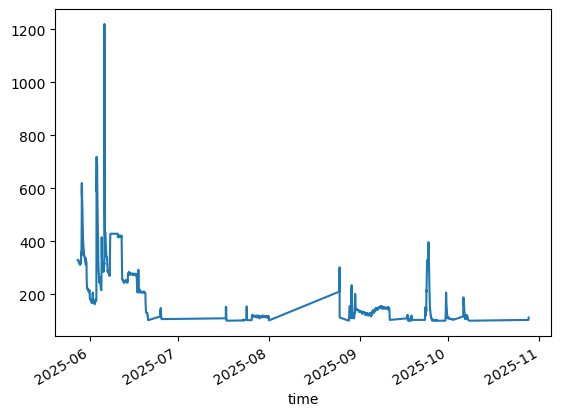

In [100]:
# Filter for specific date window
gauge = gauge.loc['2025-05':'2025-10'] #what is loc coming up next!

# Plot time-series of discharge
gauge['Discharge'].plot()

:::{admonition}
### Exercise 6: Filtering DataFrame by time index

1. Can you write a line of code to filter for only data during 2025? 

2. Now, can you filter for data between June 1 and June 21, 2025?

Bonus: Can you plot your resulting temperature data?

Spend 3 minutes working on your own then spend 1 minute disucssing your answers with your neighbor.

:::

:::{dropdown}
### Answers

1. `gauge.loc['2025']`

2. `gauge.loc['2025-06-01':'2025-06-21']`

Bonus: `gauge.loc['2025-06-01':'2025-06-21', 'Temperature'].plot()` or `gauge.loc['2025-06-01':'2025-06-21']['Temperature'].plot()` 
:::

## Break
Let's take a short break and catch our breath...

## Filtering DataFrames

We've already done a small bit of dataframe filtering, using the time index we created. We can also filter using columns and combinations of columns.

So let's take one step back and ask a general question.  We learned about booleans and comparisons in our first lesson.
> What would happen if we used a comparison on a pandas dataframe?

Give this a think:
`gauge['Temperature'] > 10`

The answer?  We get another dataframe. This dataframe is the size and shape as the thing used in comparison, but it is full of Boolean values telling us if the comparsion was true.

It turns out that we can use the same operators (`==`, `!=`, `>`, etc.) that we learned in lesson 1, only now they are contained within the DataFrame `[]` syntax we just learned. `and` and `or` operators work too, only we have to slightly modify our syntax:

| Python      | Pandas |
| :-----------: | :-----------: |
| and      | &       |
| or   | &#124;       |

You also have to be sure to wrap each individual conditional statement in parenthesis `()`.

In [97]:
# Notice dtype bool
gauge['Temperature'] > 10

time
2025-05-27 22:30:00+00:00     True
2025-05-27 22:45:00+00:00     True
2025-05-27 23:00:00+00:00     True
2025-05-27 23:15:00+00:00     True
2025-05-27 23:30:00+00:00     True
                             ...  
2025-10-31 22:45:00+00:00    False
2025-10-31 23:00:00+00:00    False
2025-10-31 23:15:00+00:00    False
2025-10-31 23:30:00+00:00    False
2025-10-31 23:45:00+00:00    False
Name: Temperature, Length: 15057, dtype: bool

In [99]:
print(gauge.shape)

# Filter only for data where temp was above 10 C
gauge = gauge.loc[gauge['Temperature'] > 10, :]

# Can also be achieved with 
# gauge = gauge[gauge['Temperature'] > 10]

# Look how the shape of our data changed
print(gauge.shape)

# Filter only for data where temp was above 10 C and discharge above 100 cubic ft per second
gauge = gauge.loc[(gauge['Temperature'] > 10) & (gauge['Discharge'] > 100), :]

# Look how the shape of our data changed
print(gauge.shape)

# Filter only for data weith approved status
gauge = gauge.loc[gauge['approval_status'] == 'Approved', :]

# Look how the shape of our data changed
print(gauge.shape)
gauge

(5224, 3)
(5224, 3)
(5224, 3)
(5224, 3)


,Temperature,Discharge,approval_status
time,,,
2025-05-27 22:30:00+00:00,18.6,330.0,Approved
2025-05-27 22:45:00+00:00,18.6,330.0,Approved
2025-05-27 23:00:00+00:00,18.7,330.0,Approved
2025-05-27 23:15:00+00:00,18.6,330.0,Approved
2025-05-27 23:30:00+00:00,18.6,330.0,Approved
...,...,...,...
2025-10-28 07:30:00+00:00,10.6,107.0,Approved
2025-10-28 07:45:00+00:00,10.6,107.0,Approved
2025-10-28 08:00:00+00:00,10.4,110.0,Approved


## DataFrame Aggregations

One of the key operations we might want to do with tabular is calculate aggregations: these are things like the count of the items, the first and last values, the minumum and maximum values, the sum of the values, and so on.

`pandas` provides functions for all the aggregations you could want to achieve.

![aggregations](images/pandas_aggregations.png)

_Table from [jakevdp's Python Data Science Handbook](https://jakevdp.github.io/PythonDataScienceHandbook/03.08-aggregation-and-grouping.html)_

In [59]:
print('discharge min', gauge['Discharge'].min())
print('temp median', gauge['Temperature'].median())

# For all columns
gauge.max()

discharge min 16.1
temp median 19.7


Temperature               27.3
Discharge               1220.0
approval_status       Approved
date                2025-10-31
year                      2025
doy                        304
test               mynewcolumn
dtype: object

:::{admonition}
### Exercise 7: Practice filtering and aggregating DataFrames

Now it's your turn to work with our stream gauge data. Can you find the answers to these questions? You'll likely need to use a mix of filtering and aggregations. 

Spend 5 minutes working on your own then spend 1 minute disucssing your answers with your neighbor.

1. Standard deviation in temperature.

2. Maximum discharge for data that is of 'provisional' status.

3. Most frequenct discharge value during 2026, and the number of times it occurred. 

:::

In [60]:
# Please work with this data - run this first then apply your filtering and aggregations

# Read in the data - this time specify correct filepath
filepath = '../data/usgs_streamgauge_06711565.xlsx' # this time we fixed the relative path
gauge = pd.read_excel(filepath)

# Data cleaning / preparation
gauge = gauge.dropna(axis=1, how='all')
gauge = gauge[['time', 'T_degC', 'Q_ft3s-1', 'approval_status']]
gauge[['T_degC', 'Q_ft3s-1']] = gauge[['T_degC', 'Q_ft3s-1']].astype(float)
gauge = gauge.dropna(subset=['T_degC', 'Q_ft3s-1'], how='any')
new_colnames = {'T_degC':'Temperature', 
                 'Q_ft3s-1':'Discharge'}
gauge = gauge.rename(columns=new_colnames)

# Set time column to datetime and set as the index of the dataframe
gauge['time'] = pd.to_datetime(gauge['time'])
gauge.set_index('time', inplace=True)
gauge

,Temperature,Discharge,approval_status
time,,,
2026-05-27 21:15:00+00:00,18.8,46.6,Provisional
2026-05-27 21:00:00+00:00,18.8,48.7,Provisional
2026-05-27 20:45:00+00:00,18.7,48.7,Provisional
2026-05-27 20:30:00+00:00,18.7,48.7,Provisional
2026-05-27 20:15:00+00:00,18.6,48.7,Provisional
...,...,...,...
2025-05-27 23:30:00+00:00,18.6,330.0,Approved
2025-05-27 23:15:00+00:00,18.6,330.0,Approved
2025-05-27 23:00:00+00:00,18.7,330.0,Approved


:::{dropdown}
### Answers

1. `gauge['Temperature'].std()`

`6.629553217728054`

2. `gauge.loc[gauge['approval_status'] == 'Provisional', ['Discharge']].max()`

`340.0`

3. `gauge.loc['2026', ['Discharge']].value_counts()`

`37.0 , 1095 times`
:::

## Writing tabular data

Now that we have processed our data, we might want to save it for later. We can do this easily with `to_csv()`.

In [30]:
output_filepath = '../data/usgs_streamgauge_06711565_processed.csv'
gauge.to_csv(output_filepath, index=True) # use False to not save the index as its own column

:::{hint}
## Bonus concept: File compression

The tabular data we are working with currently isn't big enough in size to really worry about file size. However, tabular data can sometimes contain many millions or rows and/or columns, and with certain data types (for example, floats take up more memory size than intergers), the file sizes can become big enough for this to be a practical issue that needs addressing. Besides very large files, it is good practice to think early on about ways to make your data more lightweight.

One way to do this with tabular data is to use gzip compression when saving to csv. It is a straightforward modification of the `to_csv` function we just used, and we can check the effect this has on the file size. Helpfully, the syntax to read the compressed version of the csv file is exactly the same as before.

```
output_filepath = '../data/usgs_streamgauge_06711565_processed.csv.gz' # added the .gz suffix
gauge.to_csv(output_filepath, index=True, compression="gzip") # added the compression argument

# To read back into pandas dataframe from compressed file
gauge = pd.read_csv(output_filepath)

```

:::

In [57]:
import os

output_filepath = '../data/usgs_streamgauge_06711565_processed.csv.gz' # added the .gz suffix
gauge.to_csv(output_filepath, index=True, compression="gzip") # added the compression argument

# Compare file sizes
original_size = os.path.getsize('../data/usgs_streamgauge_06711565_processed.csv')
compressed_size = os.path.getsize('../data/usgs_streamgauge_06711565_processed.csv.gz')

print(f"Original: {original_size / 1024:.0f} KB")
print(f"Compressed: {compressed_size / 1024:.0f} KB")
print(f"Reduction: {(1 - compressed_size/original_size)*100:.1f}%")

Original: 1571 KB
Compressed: 66 KB
Reduction: 95.8%


:::{danger}
## Exit ticket!

This is your ticket outta here. Before you leave this lesson, please submit your responses to the following questions using this link: INSERT LINK

* Give an overall rating of how much of this lesson's content you feel you are now comfortable with? Indicate on a 0-10 scale, with 10 being you are comfortable with all of the content.
* How was the pace of this lesson for you? 1) Too slow; 2) About right; 3) Too fast.
* Briefly, what was the single concept you found most challenging in this lesson? 

:::

:::{hint}
## Further reading

More pandas functions, especially `pd.concat()`, `pd.merge()`, `quantile()`, `pivot()`, `melt()`, and `pivot_table()`: https://www.kdnuggets.com/10-essential-pandas-functions-every-data-scientist-should-know

MetPy Mondays videos:
* [93 Pandas and Datetime Indexes](https://youtu.be/lGZCP_3uN2U?si=MSa7lm_rl485jHhn)
* [97 Pandas concat](https://youtu.be/rj2ZEAIbg1k?si=SMrAsLEBMKOLbW8M)
* [98 Pandas merge and join](https://youtu.be/rj2ZEAIbg1k?si=SxDN6P1d10zisd43)
* [133 Timezones](https://youtu.be/IIriyfUmKgQ?si=9iWuc_F-9-e1rwPb)
:::